In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load the cleaned ClimaCare dataset
data_path = Path("../data/processed/climacare_clean.csv")

df = pd.read_csv(data_path)

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

print("ClimaCare UAE AI — EDA Started")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

df.head()

ClimaCare UAE AI — EDA Started
Dataset loaded successfully!
Shape: (1294, 15)
Date range: 2022-08-05 00:00:00 to 2026-02-18 00:00:00


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi,temperature,humidity,wind_speed
0,2022-08-05,86.758333,53.945833,737.458333,106.075000,30.816667,48.083333,0.510833,25.458333,2.039583,142.850000,82.150000,35.033333,58.791667,10.570833
1,2022-08-06,105.070833,66.250000,889.500000,137.662500,34.558333,43.291667,0.513333,30.125000,2.131250,152.083333,88.041667,36.204167,45.416667,10.158333
2,2022-08-07,150.691667,93.758333,813.583333,119.616667,23.904167,120.000000,0.573333,41.041667,1.889583,180.291667,98.416667,37.495833,33.208333,12.337500
3,2022-08-08,103.125000,62.745833,607.625000,94.858333,18.945833,152.666667,0.353750,29.250000,2.272917,207.166667,109.583333,38.366667,35.583333,10.900000
4,2022-08-09,76.595833,45.358333,602.625000,107.912500,24.212500,63.375000,0.339167,26.083333,2.366667,146.791667,85.625000,36.750000,44.541667,11.462500


In [2]:
# Check dataset structure and data types
print("Dataset information:")
print("-" * 50)

df.info()

print("\nStatistical summary:")
display(df.describe())

Dataset information:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1294 entries, 0 to 1293
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   1294 non-null   datetime64[us]
 1   pm10                   1294 non-null   float64       
 2   pm2_5                  1294 non-null   float64       
 3   carbon_monoxide        1294 non-null   float64       
 4   nitrogen_dioxide       1294 non-null   float64       
 5   sulphur_dioxide        1294 non-null   float64       
 6   ozone                  1294 non-null   float64       
 7   aerosol_optical_depth  1294 non-null   float64       
 8   dust                   1294 non-null   float64       
 9   uv_index               1294 non-null   float64       
 10  us_aqi                 1294 non-null   float64       
 11  european_aqi           1294 non-null   float64       
 12  t

,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi,temperature,humidity,wind_speed
count,1294,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000
mean,2024-05-12 12:00:00,94.322331,40.660942,441.594378,49.700003,21.731643,83.525824,0.377458,92.171722,1.693323,114.348834,79.148396,28.062284,57.186888,12.563286
min,2022-08-05 00:00:00,0.900000,0.620833,60.708333,0.000000,0.220833,10.583333,0.035000,0.000000,0.208333,15.791667,13.958333,15.625000,9.583333,6.512500
25%,2023-06-24 06:00:00,57.171875,29.827083,348.197917,33.347917,16.243750,59.083333,0.252604,26.593750,1.139583,90.468750,66.468750,22.508333,49.500000,9.976042
50%,2024-05-12 12:00:00,78.475000,39.520833,433.208333,44.497917,21.829167,80.395833,0.342500,54.104167,1.766667,112.312500,74.229167,28.102083,57.791667,11.718750
75%,2025-03-31 18:00:00,117.513542,49.557292,520.458333,58.726042,27.125000,103.270833,0.473229,118.062500,2.174479,139.250000,88.031250,33.682292,65.958333,14.448958
max,2026-02-18 00:00:00,357.750000,116.433333,1071.583333,180.391667,52.220833,220.333333,1.074167,771.958333,2.831250,235.250000,191.583333,39.533333,88.375000,27.262500
std,NaN,52.642001,14.332587,134.270139,26.082960,7.974727,33.901367,0.171927,100.926916,0.573089,30.221127,20.863453,6.152079,12.196672,3.472825


Matplotlib is building the font cache; this may take a moment.


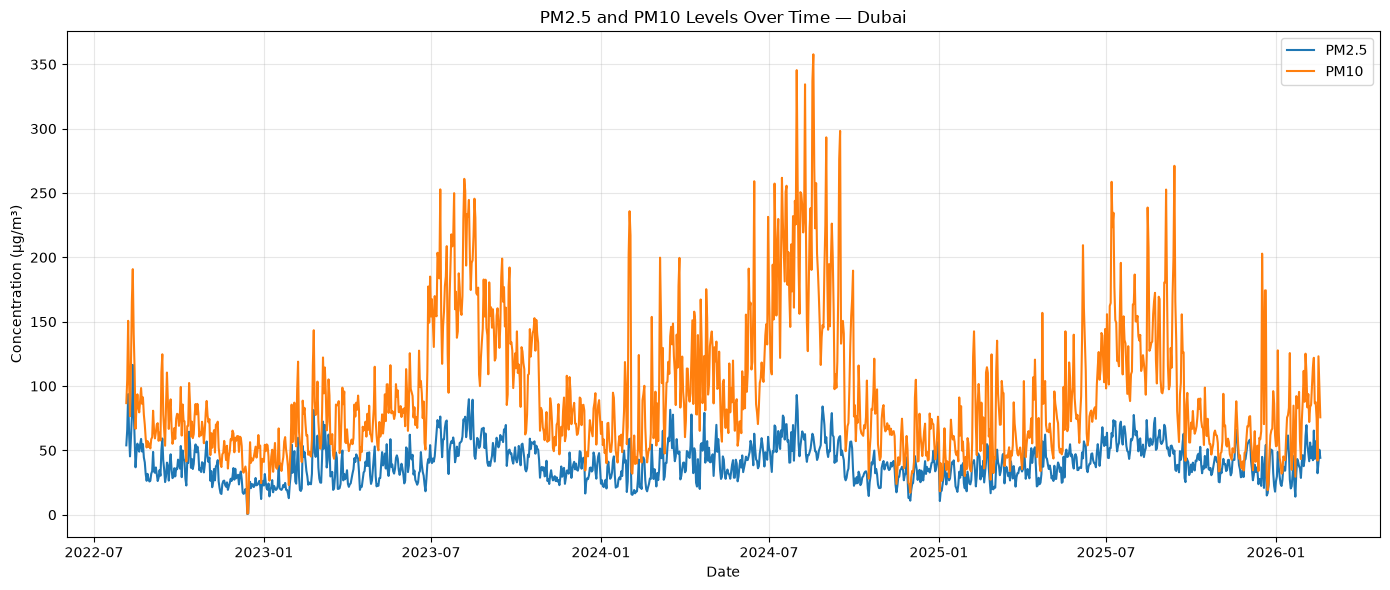

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(df["date"], df["pm2_5"], label="PM2.5")
plt.plot(df["date"], df["pm10"], label="PM10")

plt.title("PM2.5 and PM10 Levels Over Time — Dubai")
plt.xlabel("Date")
plt.ylabel("Concentration (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

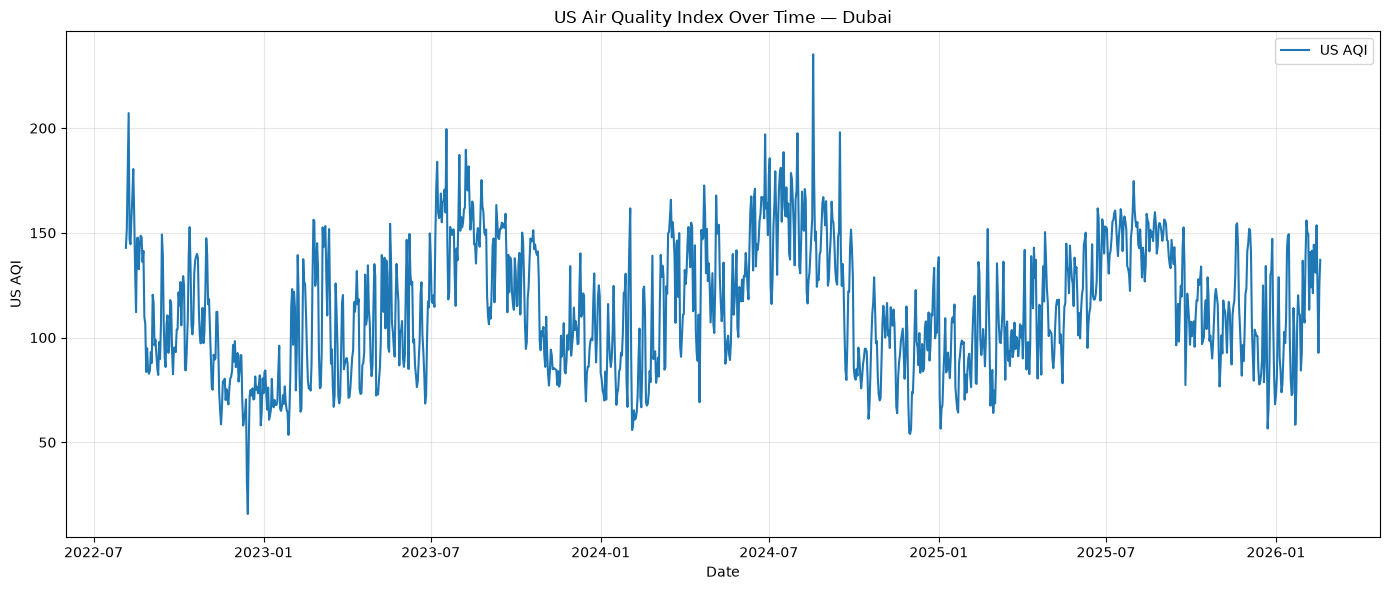

In [4]:
plt.figure(figsize=(14, 6))

plt.plot(df["date"], df["us_aqi"], label="US AQI")

plt.title("US Air Quality Index Over Time — Dubai")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Correlation analysis

numeric_df = df.drop(columns=["date"])

correlation = numeric_df.corr()

# Show correlation with US AQI
aqi_correlation = correlation["us_aqi"].sort_values(ascending=False)

print("Correlation of features with US AQI:")
print(aqi_correlation)

Correlation of features with US AQI:
us_aqi                   1.000000
pm2_5                    0.886980
european_aqi             0.842416
pm10                     0.745428
aerosol_optical_depth    0.620341
temperature              0.602707
dust                     0.542762
uv_index                 0.412007
ozone                    0.357555
carbon_monoxide          0.355267
sulphur_dioxide          0.348577
nitrogen_dioxide         0.112714
wind_speed              -0.065561
humidity                -0.246438
Name: us_aqi, dtype: float64


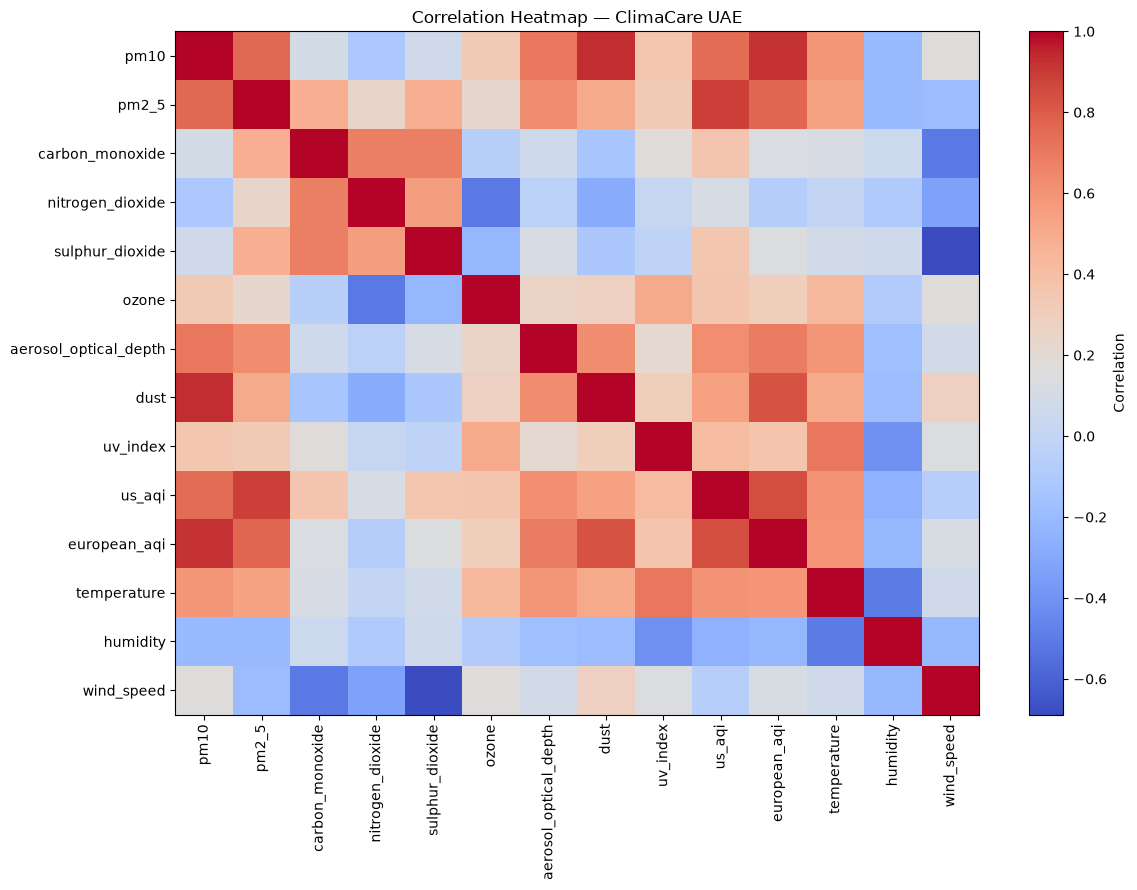

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap — ClimaCare UAE")
plt.tight_layout()
plt.show()

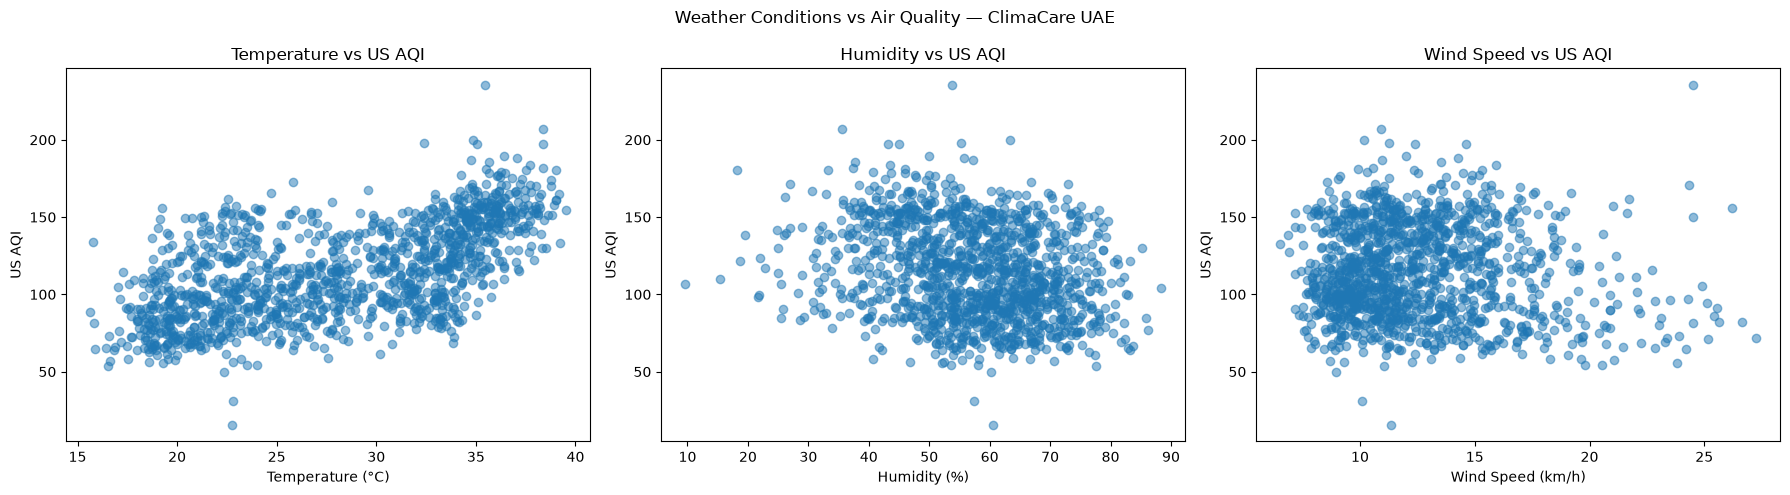

In [7]:
# Weather factors vs US AQI

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["temperature"], df["us_aqi"], alpha=0.5)
axes[0].set_title("Temperature vs US AQI")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("US AQI")

axes[1].scatter(df["humidity"], df["us_aqi"], alpha=0.5)
axes[1].set_title("Humidity vs US AQI")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("US AQI")

axes[2].scatter(df["wind_speed"], df["us_aqi"], alpha=0.5)
axes[2].set_title("Wind Speed vs US AQI")
axes[2].set_xlabel("Wind Speed (km/h)")
axes[2].set_ylabel("US AQI")

plt.suptitle("Weather Conditions vs Air Quality — ClimaCare UAE")
plt.tight_layout()
plt.show()

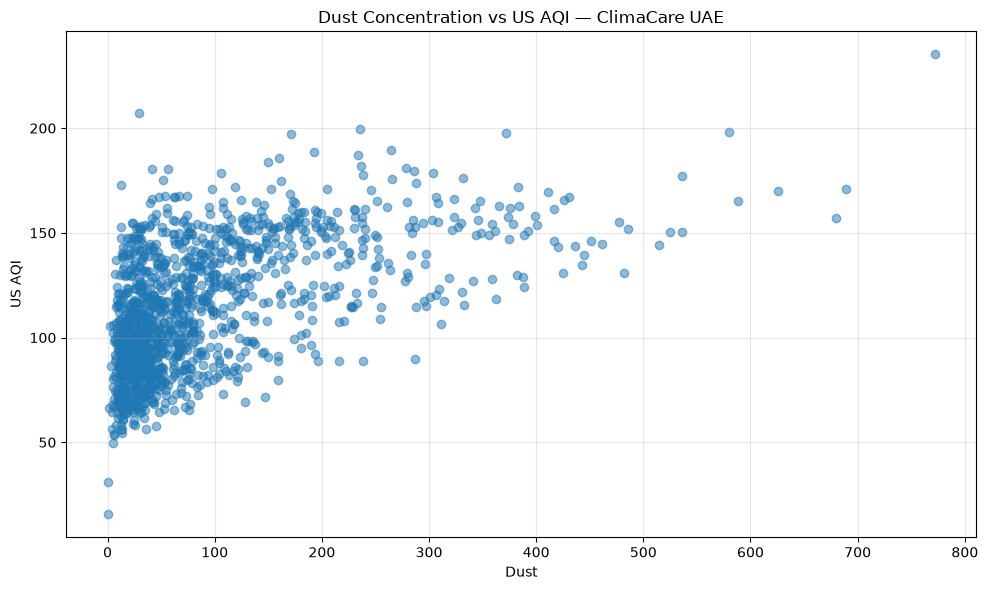

In [8]:
# Dust vs US AQI

plt.figure(figsize=(10, 6))

plt.scatter(df["dust"], df["us_aqi"], alpha=0.5)

plt.title("Dust Concentration vs US AQI — ClimaCare UAE")
plt.xlabel("Dust")
plt.ylabel("US AQI")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np

# Load cleaned ClimaCare dataset
data_path = Path("../data/processed/climacare_clean.csv")

df = pd.read_csv(data_path)

# Convert date
df["date"] = pd.to_datetime(df["date"])

print("Dataset loaded for feature engineering")
print("Shape:", df.shape)
print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

df.head()

Dataset loaded for feature engineering
Shape: (1294, 15)

Date range:
2022-08-05 00:00:00 to 2026-02-18 00:00:00


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi,temperature,humidity,wind_speed
0,2022-08-05,86.758333,53.945833,737.458333,106.075000,30.816667,48.083333,0.510833,25.458333,2.039583,142.850000,82.150000,35.033333,58.791667,10.570833
1,2022-08-06,105.070833,66.250000,889.500000,137.662500,34.558333,43.291667,0.513333,30.125000,2.131250,152.083333,88.041667,36.204167,45.416667,10.158333
2,2022-08-07,150.691667,93.758333,813.583333,119.616667,23.904167,120.000000,0.573333,41.041667,1.889583,180.291667,98.416667,37.495833,33.208333,12.337500
3,2022-08-08,103.125000,62.745833,607.625000,94.858333,18.945833,152.666667,0.353750,29.250000,2.272917,207.166667,109.583333,38.366667,35.583333,10.900000
4,2022-08-09,76.595833,45.358333,602.625000,107.912500,24.212500,63.375000,0.339167,26.083333,2.366667,146.791667,85.625000,36.750000,44.541667,11.462500


In [10]:
# Create time-based features from the date

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

print("Time-based features created successfully!")

df[["date", "year", "month", "day", "day_of_week"]].head(10)

Time-based features created successfully!


,date,year,month,day,day_of_week
0,2022-08-05,2022,8,5,4
1,2022-08-06,2022,8,6,5
2,2022-08-07,2022,8,7,6
3,2022-08-08,2022,8,8,0
4,2022-08-09,2022,8,9,1
5,2022-08-10,2022,8,10,2
6,2022-08-11,2022,8,11,3
7,2022-08-12,2022,8,12,4
8,2022-08-13,2022,8,13,5
9,2022-08-14,2022,8,14,6


In [11]:
# Create UAE seasonal feature

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

print("Season feature created successfully!")
print(df["season"].value_counts())

df[["date", "month", "season"]].head(10)

Season feature created successfully!
season
Autumn    364
Winter    351
Summer    303
Spring    276
Name: count, dtype: int64


,date,month,season
0,2022-08-05,8,Summer
1,2022-08-06,8,Summer
2,2022-08-07,8,Summer
3,2022-08-08,8,Summer
4,2022-08-09,8,Summer
5,2022-08-10,8,Summer
6,2022-08-11,8,Summer
7,2022-08-12,8,Summer
8,2022-08-13,8,Summer
9,2022-08-14,8,Summer


In [12]:
# Create lag features for previous-day air quality

df["pm2_5_lag1"] = df["pm2_5"].shift(1)
df["pm10_lag1"] = df["pm10"].shift(1)
df["us_aqi_lag1"] = df["us_aqi"].shift(1)

print("Lag features created successfully!")

df[[
    "date",
    "pm2_5", "pm2_5_lag1",
    "pm10", "pm10_lag1",
    "us_aqi", "us_aqi_lag1"
]].head(10)

Lag features created successfully!


,date,pm2_5,pm2_5_lag1,pm10,pm10_lag1,us_aqi,us_aqi_lag1
0,2022-08-05,53.945833,NaN,86.758333,NaN,142.850000,NaN
1,2022-08-06,66.250000,53.945833,105.070833,86.758333,152.083333,142.850000
2,2022-08-07,93.758333,66.250000,150.691667,105.070833,180.291667,152.083333
3,2022-08-08,62.745833,93.758333,103.125000,150.691667,207.166667,180.291667
4,2022-08-09,45.358333,62.745833,76.595833,103.125000,146.791667,207.166667
5,2022-08-10,59.287500,45.358333,114.862500,76.595833,144.583333,146.791667
6,2022-08-11,75.741667,59.287500,165.525000,114.862500,157.083333,144.583333
7,2022-08-12,116.433333,75.741667,190.825000,165.525000,167.625000,157.083333
8,2022-08-13,81.566667,116.433333,140.454167,190.825000,180.500000,167.625000
9,2022-08-14,58.629167,81.566667,111.983333,140.454167,158.333333,180.500000


In [13]:
# Create 3-day rolling average features using previous days only

df["pm2_5_roll3"] = df["pm2_5"].shift(1).rolling(window=3).mean()
df["pm10_roll3"] = df["pm10"].shift(1).rolling(window=3).mean()
df["us_aqi_roll3"] = df["us_aqi"].shift(1).rolling(window=3).mean()

print("3-day rolling features created successfully!")

df[[
    "date",
    "pm2_5", "pm2_5_roll3",
    "pm10", "pm10_roll3",
    "us_aqi", "us_aqi_roll3"
]].head(10)

3-day rolling features created successfully!


,date,pm2_5,pm2_5_roll3,pm10,pm10_roll3,us_aqi,us_aqi_roll3
0,2022-08-05,53.945833,NaN,86.758333,NaN,142.850000,NaN
1,2022-08-06,66.250000,NaN,105.070833,NaN,152.083333,NaN
2,2022-08-07,93.758333,NaN,150.691667,NaN,180.291667,NaN
3,2022-08-08,62.745833,71.318056,103.125000,114.173611,207.166667,158.408333
4,2022-08-09,45.358333,74.251389,76.595833,119.629167,146.791667,179.847222
5,2022-08-10,59.287500,67.287500,114.862500,110.137500,144.583333,178.083333
6,2022-08-11,75.741667,55.797222,165.525000,98.194444,157.083333,166.180556
7,2022-08-12,116.433333,60.129167,190.825000,118.994444,167.625000,149.486111
8,2022-08-13,81.566667,83.820833,140.454167,157.070833,180.500000,156.430556
9,2022-08-14,58.629167,91.247222,111.983333,165.601389,158.333333,168.402778


In [14]:
# Create interaction features

df["pm_ratio"] = df["pm2_5"] / (df["pm10"] + 1e-6)

df["dust_wind"] = df["dust"] / (df["wind_speed"] + 1e-6)

df["temp_humidity"] = df["temperature"] * df["humidity"]

print("Interaction features created successfully!")

df[[
    "date",
    "pm_ratio",
    "dust_wind",
    "temp_humidity"
]].head(10)

Interaction features created successfully!


,date,pm_ratio,dust_wind,temp_humidity
0,2022-08-05,0.621794,2.408356,2059.668056
1,2022-08-06,0.630527,2.965545,1644.272569
2,2022-08-07,0.622187,3.326579,1245.174132
3,2022-08-08,0.608444,2.683486,1365.213889
4,2022-08-09,0.592178,2.275536,1636.906250
5,2022-08-10,0.516161,5.325149,1954.739583
6,2022-08-11,0.457584,11.379800,1966.703125
7,2022-08-12,0.610158,4.111852,1559.029687
8,2022-08-13,0.580735,3.685784,709.105556
9,2022-08-14,0.523553,4.984520,1295.061806


In [15]:
# Encode season as numerical values

season_mapping = {
    "Winter": 0,
    "Spring": 1,
    "Summer": 2,
    "Autumn": 3
}

df["season_encoded"] = df["season"].map(season_mapping)

print("Season encoded successfully!")

print(df[["season", "season_encoded"]].drop_duplicates()
      .sort_values("season_encoded"))

print("\nMissing encoded values:", df["season_encoded"].isna().sum())

Season encoded successfully!
     season  season_encoded
118  Winter               0
208  Spring               1
0    Summer               2
27   Autumn               3

Missing encoded values: 0


In [16]:
# Check missing values in engineered features

engineered_features = [
    "pm2_5_lag1",
    "pm10_lag1",
    "us_aqi_lag1",
    "pm2_5_roll3",
    "pm10_roll3",
    "us_aqi_roll3"
]

print("Missing values before removal:")
print(df[engineered_features].isnull().sum())

# Remove rows missing lag/rolling history
df_model = df.dropna(subset=engineered_features).copy()

# Reset index
df_model.reset_index(drop=True, inplace=True)

print("\nRows before:", len(df))
print("Rows after:", len(df_model))

print("\nRemaining missing values in engineered features:")
print(df_model[engineered_features].isnull().sum())

df_model.head()

Missing values before removal:
pm2_5_lag1      1
pm10_lag1       1
us_aqi_lag1     1
pm2_5_roll3     3
pm10_roll3      3
us_aqi_roll3    3
dtype: int64

Rows before: 1294
Rows after: 1291

Remaining missing values in engineered features:
pm2_5_lag1      0
pm10_lag1       0
us_aqi_lag1     0
pm2_5_roll3     0
pm10_roll3      0
us_aqi_roll3    0
dtype: int64


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,...,pm2_5_lag1,pm10_lag1,us_aqi_lag1,pm2_5_roll3,pm10_roll3,us_aqi_roll3,pm_ratio,dust_wind,temp_humidity,season_encoded
0,2022-08-08,103.125000,62.745833,607.625000,94.858333,18.945833,152.666667,0.353750,29.250000,2.272917,...,93.758333,150.691667,180.291667,71.318056,114.173611,158.408333,0.608444,2.683486,1365.213889,2
1,2022-08-09,76.595833,45.358333,602.625000,107.912500,24.212500,63.375000,0.339167,26.083333,2.366667,...,62.745833,103.125000,207.166667,74.251389,119.629167,179.847222,0.592178,2.275536,1636.906250,2
2,2022-08-10,114.862500,59.287500,766.916667,115.254167,26.708333,99.541667,0.485000,66.875000,2.141667,...,45.358333,76.595833,146.791667,67.287500,110.137500,178.083333,0.516161,5.325149,1954.739583,2
3,2022-08-11,165.525000,75.741667,938.333333,137.954167,36.704167,72.916667,0.634167,133.333333,1.954167,...,59.287500,114.862500,144.583333,55.797222,98.194444,166.180556,0.457584,11.379800,1966.703125,2
4,2022-08-12,190.825000,116.433333,1071.583333,117.541667,25.470833,105.625000,0.738333,53.916667,1.887500,...,75.741667,165.525000,157.083333,60.129167,118.994444,149.486111,0.610158,4.111852,1559.029687,2


In [17]:
# Save the feature-engineered dataset

output_path = Path("../data/processed/climacare_features.csv")

df_model.to_csv(output_path, index=False)

print("Feature-engineered dataset saved successfully!")
print("Saved to:", output_path)
print("Final shape:", df_model.shape)
print("Date range:", df_model["date"].min(), "to", df_model["date"].max())

Feature-engineered dataset saved successfully!
Saved to: ../data/processed/climacare_features.csv
Final shape: (1291, 30)
Date range: 2022-08-08 00:00:00 to 2026-02-18 00:00:00
